# Retail Sales Data - Exploratory Data Analysis


### Objective

Perform a thorough Exploratory Data Analysis (EDA) on a retail sales
dataset to uncover sales patterns, customer behaviour trends,
product performance, and actionable business insights.

### Tech Stack

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

### Dataset

The dataset contains retail transaction information including
customer demographics, products, categories, quantity, pricing,
sales, discounts, and revenue.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

## 1. Loading the Dataset

The retail sales dataset is loaded using Pandas for further
exploration, cleaning, visualization, and analysis.

In [2]:
df = pd.read_csv("retail_sales_eda_dataset.csv")

df.head()

,Order_ID,Date,Customer_ID,Gender,Age,Product,Category,Quantity,Unit_Price,Sales,Discount_Percent,Discount_Amount,Revenue
0,ORD0001,2025-01-05 00:00:00.000000000,CUST0054,Male,45,Bluetooth Speaker,Electronics,3,126.62,410.44,20,82.09,328.35
1,ORD0002,2025-01-08 17:32:46.386554621,CUST0022,Female,42,Power Bank,Electronics,5,100.02,573.83,15,86.07,487.76
2,ORD0003,2025-01-12 11:05:32.773109243,CUST0043,Female,56,Cookware Set,Home & Kitchen,4,55.19,229.94,0,0.00,229.94
3,ORD0004,2025-01-16 04:38:19.159663865,CUST0046,Female,50,Table Lamp,Home & Kitchen,5,59.44,293.16,15,43.97,249.19
4,ORD0005,2025-01-19 22:11:05.546218487,CUST0004,Male,18,Storage Box,Home & Kitchen,4,100.70,371.77,15,55.77,316.00


## 2. Initial Dataset Inspection

Before performing analysis, the dataset is inspected to understand
its size, structure, data types, missing values, and duplicate records.

In [3]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("Dataset Shape:", df.shape)

Number of Rows: 120
Number of Columns: 13
Dataset Shape: (120, 13)


### Dataset Information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          120 non-null    str    
 1   Date              120 non-null    str    
 2   Customer_ID       120 non-null    str    
 3   Gender            120 non-null    str    
 4   Age               120 non-null    int64  
 5   Product           120 non-null    str    
 6   Category          120 non-null    str    
 7   Quantity          120 non-null    int64  
 8   Unit_Price        120 non-null    float64
 9   Sales             120 non-null    float64
 10  Discount_Percent  120 non-null    int64  
 11  Discount_Amount   120 non-null    float64
 12  Revenue           120 non-null    float64
dtypes: float64(4), int64(3), str(6)
memory usage: 12.3 KB


### Data Types

In [5]:
df.dtypes

Order_ID                str
Date                    str
Customer_ID             str
Gender                  str
Age                   int64
Product                 str
Category                str
Quantity              int64
Unit_Price          float64
Sales               float64
Discount_Percent      int64
Discount_Amount     float64
Revenue             float64
dtype: object

### Missing Values

In [6]:
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
Order_ID            0
Date                0
Customer_ID         0
Gender              0
Age                 0
Product             0
Category            0
Quantity            0
Unit_Price          0
Sales               0
Discount_Percent    0
Discount_Amount     0
Revenue             0
dtype: int64


### Duplicate Check

In [7]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


## 3. Data Cleaning and Preparation

The Date column is converted into datetime format so that monthly
and quarterly sales trends can be analyzed effectively.

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[ns]


### Creating Time Features

In [10]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.quarter

df.head()

,Order_ID,Date,Customer_ID,Gender,Age,Product,Category,Quantity,Unit_Price,Sales,Discount_Percent,Discount_Amount,Revenue,Year,Month,Month_Name,Quarter
0,ORD0001,2025-01-05 00:00:00.000000000,CUST0054,Male,45,Bluetooth Speaker,Electronics,3,126.62,410.44,20,82.09,328.35,2025,1,January,1
1,ORD0002,2025-01-08 17:32:46.386554621,CUST0022,Female,42,Power Bank,Electronics,5,100.02,573.83,15,86.07,487.76,2025,1,January,1
2,ORD0003,2025-01-12 11:05:32.773109243,CUST0043,Female,56,Cookware Set,Home & Kitchen,4,55.19,229.94,0,0.00,229.94,2025,1,January,1
3,ORD0004,2025-01-16 04:38:19.159663865,CUST0046,Female,50,Table Lamp,Home & Kitchen,5,59.44,293.16,15,43.97,249.19,2025,1,January,1
4,ORD0005,2025-01-19 22:11:05.546218487,CUST0004,Male,18,Storage Box,Home & Kitchen,4,100.70,371.77,15,55.77,316.00,2025,1,January,1


## 4. Descriptive Statistics

Descriptive statistics are calculated for numerical variables to
understand their central tendency and variability.

In [11]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(list(numeric_columns))

Numerical Columns:
['Age', 'Quantity', 'Unit_Price', 'Sales', 'Discount_Percent', 'Discount_Amount', 'Revenue', 'Year', 'Month', 'Quarter']


### Mean, Median, Mode & Standard Deviation

In [12]:
statistics = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std()
})

statistics

,Mean,Median,Mode,Standard Deviation
Age,40.583333,42.000,49.00,13.856154
Quantity,4.700000,5.000,6.00,1.951513
Unit_Price,77.793167,73.735,50.15,42.662808
Sales,371.710000,334.190,72.26,208.599650
Discount_Percent,6.500000,5.000,0.00,5.636019
Discount_Amount,24.281750,16.725,0.00,26.487437
Revenue,347.428250,307.315,65.03,198.909481
Year,2025.191667,2025.000,2025.00,0.395263
Month,5.641667,5.000,1.00,3.608570
Quarter,2.216667,2.000,1.00,1.168086


### Observation

The descriptive statistics provide an overview of the typical values
and variation in the numerical variables. The comparison between
mean and median can help identify whether certain variables are
skewed, while standard deviation indicates the amount of variation
around the average.

## 5. Time Series Analysis

### 5.1 Monthly Sales Trend

Monthly sales are aggregated to identify changes in sales performance
over time and detect potential seasonal patterns.

In [13]:
monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))["Sales"]
    .sum()
)

monthly_sales

Date
2025-01    3092.43
2025-02    2290.59
2025-03    3138.47
2025-04    3295.75
2025-05    2653.56
2025-06    2185.88
2025-07    2671.84
2025-08    2821.14
2025-09    3173.72
2025-10    3652.67
2025-11    4480.19
2025-12    4172.81
2026-01    2271.38
2026-02    2275.54
2026-03    2429.23
Freq: M, Name: Sales, dtype: float64

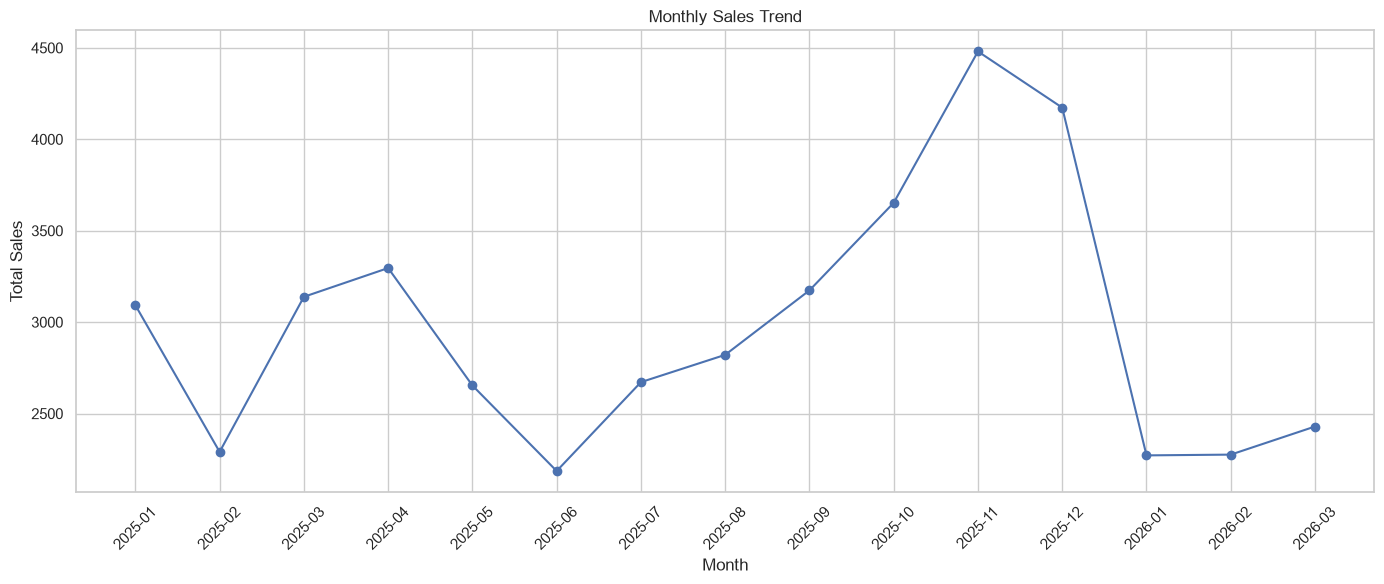

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The highest monthly sales were observed in November 2025, while the lowest
sales were observed in June 2025. This suggests that customer demand
varies across different periods.

### Highest & Lowest Sales Month

In [15]:
highest_month = monthly_sales.idxmax()
lowest_month = monthly_sales.idxmin()

print("Highest Sales Month:", highest_month)
print("Highest Sales:", monthly_sales.max())

print("\nLowest Sales Month:", lowest_month)
print("Lowest Sales:", monthly_sales.min())

Highest Sales Month: 2025-11
Highest Sales: 4480.19

Lowest Sales Month: 2025-06
Lowest Sales: 2185.88


### 5.2 Quarterly Sales Trend

Quarterly sales are analyzed to identify broader sales patterns
and compare business performance across quarters.

In [16]:
quarterly_sales = (
    df.groupby(
        [df["Date"].dt.year, df["Date"].dt.quarter]
    )["Sales"]
    .sum()
)

quarterly_sales

Date  Date
2025  1        8521.49
      2        8135.19
      3        8666.70
      4       12305.67
2026  1        6976.15
Name: Sales, dtype: float64

In [18]:
quarter_labels = [
    f"{year}-Q{quarter}"
    for year, quarter in quarterly_sales.index
]

quarter_values = quarterly_sales.values

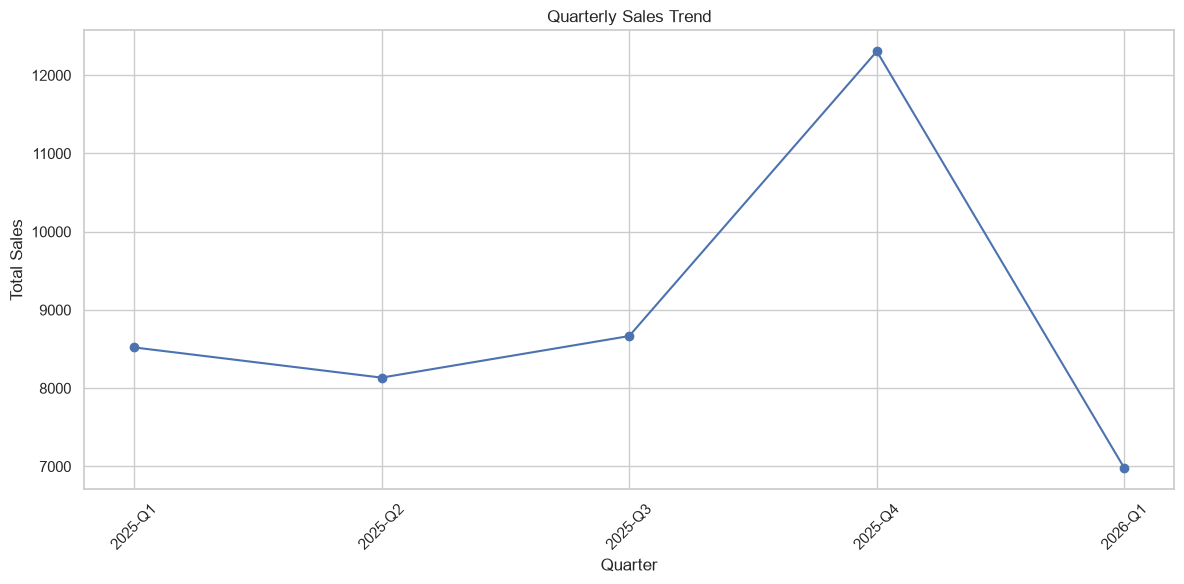

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(
    quarter_labels,
    quarter_values,
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
highest_quarter = quarterly_sales.idxmax()
lowest_quarter = quarterly_sales.idxmin()

print(
    "Highest Sales Quarter:",
    f"{highest_quarter[0]}-Q{highest_quarter[1]}"
)

print("Sales:", quarterly_sales.max())

print(
    "\nLowest Sales Quarter:",
    f"{lowest_quarter[0]}-Q{lowest_quarter[1]}"
)

print("Sales:", quarterly_sales.min())

Highest Sales Quarter: 2025-Q4
Sales: 12305.67

Lowest Sales Quarter: 2026-Q1
Sales: 6976.150000000001


### Observation
Highest Quarterly Sales were in 2025-Q4.
    
Lowest Quarterly Sales were in 2026-Q1.

The quarterly sales trend provides a broader view of business
performance. Comparing quarters helps identify periods of stronger
or weaker sales and can support inventory and promotional planning.

## 6. Customer Demographics Analysis

### 6.1 Customer Age Group Distribution

Customers are divided into age groups to understand which age
segments are most represented in the retail dataset.

In [22]:
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]

age_labels = [
    "Under 18",
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "65+"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    right=True
)

age_group_counts = (
    df["Age_Group"]
    .value_counts()
    .sort_index()
)

age_group_counts

Age_Group
Under 18     4
18-25       21
26-35       18
36-45       28
46-55       29
56-65       20
65+          0
Name: count, dtype: int64

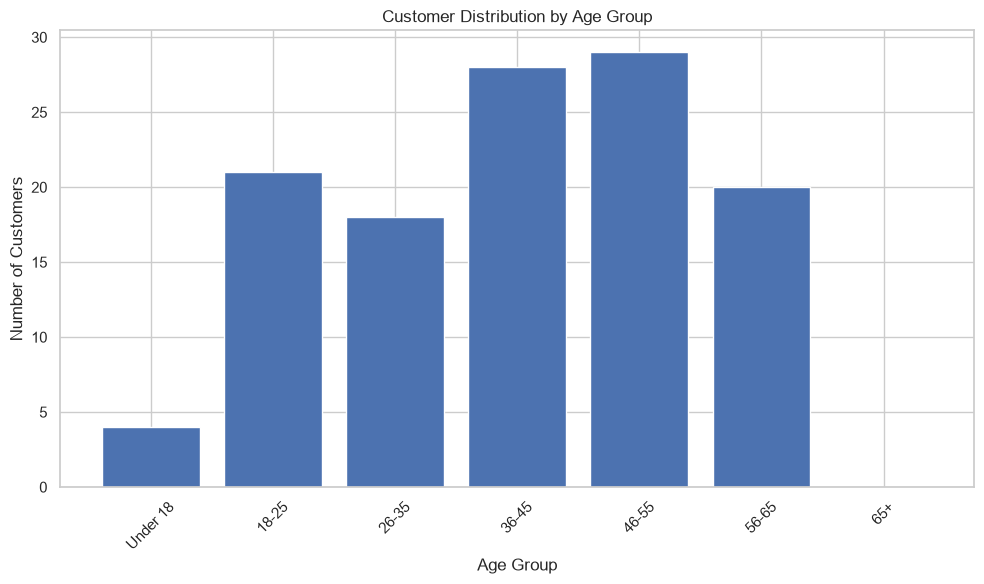

In [23]:
plt.figure(figsize=(10, 6))

plt.bar(
    age_group_counts.index.astype(str),
    age_group_counts.values
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [24]:
top_age_group = age_group_counts.idxmax()
top_age_count = age_group_counts.max()

print("Most Common Age Group:", top_age_group)
print("Number of Customers:", top_age_count)

Most Common Age Group: 46-55
Number of Customers: 29


### Observation

Most Number of Customers lies in 46-55 age group. 

The age-group distribution shows the customer segments represented
in the dataset. The most represented age group can help the business
identify its primary customer demographic and design more targeted
marketing campaigns.

### 6.2 Gender Distribution

The gender distribution of customers is analyzed to understand the
composition of the customer base.

In [25]:
gender_counts = df["Gender"].value_counts()

gender_counts

Gender
Male      60
Female    60
Name: count, dtype: int64

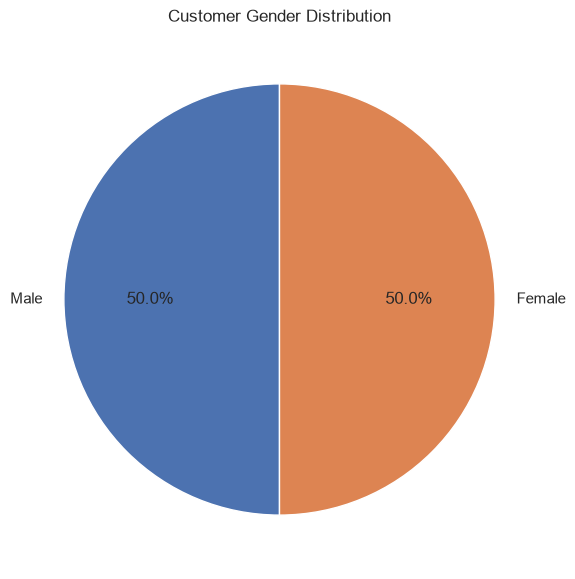

In [26]:
plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Gender Distribution")

plt.show()

### Observation

The gender distribution shows the relative representation of male
and female customers. This information can help businesses design
customer segments and targeted marketing campaigns.

## 7. Product Analysis

### 7.1 Top 10 Best-Selling Products

Products are ranked according to the total quantity sold to identify
the products with the highest sales volume.

In [27]:
top_products = (
    df.groupby("Product")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product
T-Shirt         44
Cookware Set    43
Storage Box     37
Water Bottle    34
Face Wash       33
Shampoo         30
Football        30
Hoodie          30
Table Lamp      30
Jeans           29
Name: Quantity, dtype: int64

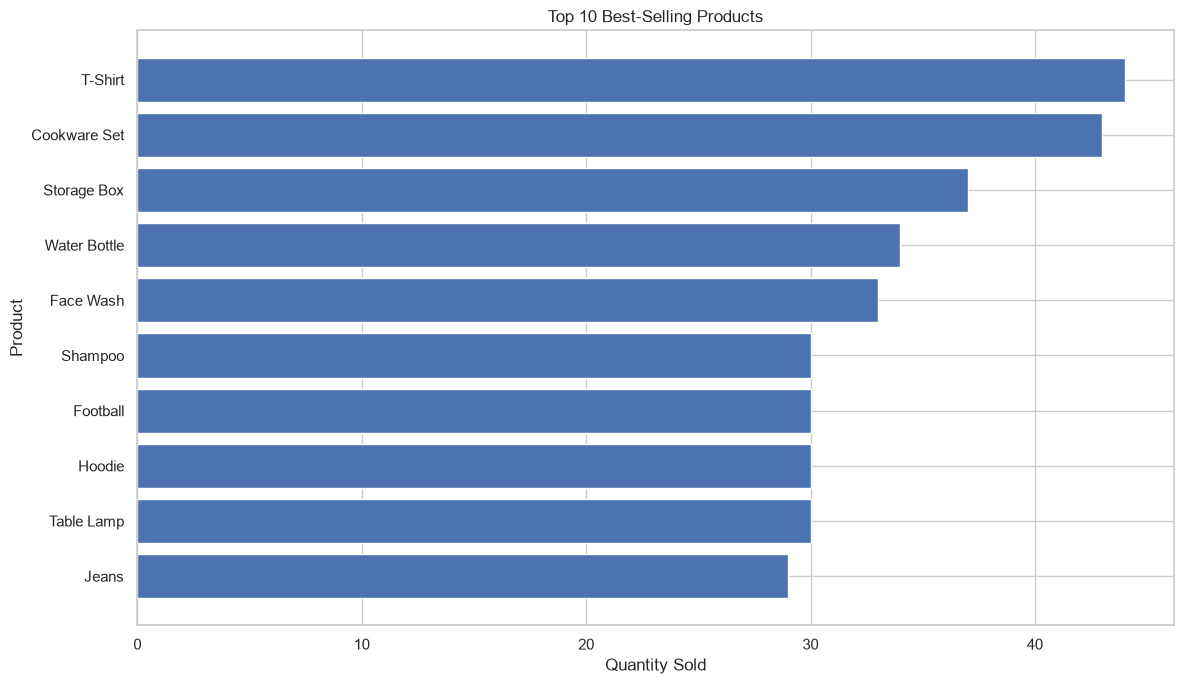

In [28]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_products.index[::-1],
    top_products.values[::-1]
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [29]:
best_product = top_products.idxmax()
best_product_quantity = top_products.max()

print("Best-Selling Product:", best_product)
print("Quantity Sold:", best_product_quantity)

Best-Selling Product: T-Shirt
Quantity Sold: 44


### Observation

Most Selling Product is T-Shirt with 44 qty.

### 7.2 Revenue by Product Category

Total revenue is aggregated by product category to identify the
categories contributing most to overall business revenue.

In [30]:
category_revenue = (
    df.groupby("Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Category
Home & Kitchen    15373.84
Electronics        8842.60
Clothing           7026.00
Beauty             5497.71
Sports             4951.24
Name: Revenue, dtype: float64

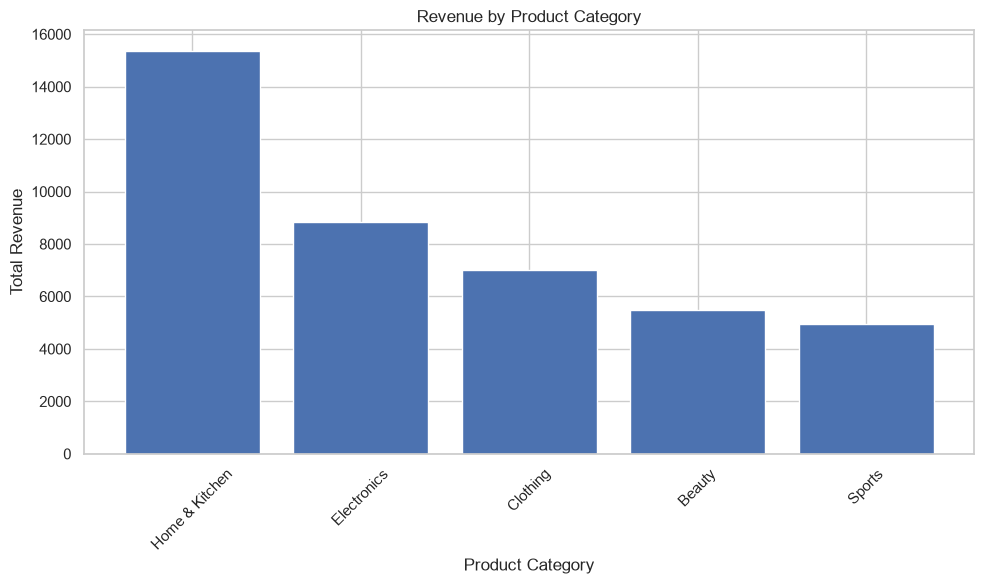

In [31]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_revenue.index,
    category_revenue.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Highest Revenue Category

In [32]:
best_category = category_revenue.idxmax()
best_category_revenue = category_revenue.max()

print("Highest Revenue Category:", best_category)
print("Revenue:", round(best_category_revenue, 2))

Highest Revenue Category: Home & Kitchen
Revenue: 15373.84


### Observation

Revenue varies across product categories. 
The highest-revenue category is Home & Kitchen who are important contributors to business performance
and should receive appropriate inventory, pricing, and promotional
attention.

## 8. Correlation Analysis

A correlation matrix is used to examine relationships between
numerical variables such as age, quantity, price, sales, discount,
and revenue.

In [33]:
correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Age,Quantity,Unit_Price,Sales,Discount_Percent,Discount_Amount,Revenue,Year,Month,Quarter
Age,1.000000,0.178382,-0.066299,0.112577,-0.161410,-0.101705,0.131605,0.126712,-0.052422,-0.073813
Quantity,0.178382,1.000000,-0.628223,0.284012,-0.107728,0.063205,0.289431,-0.055560,-0.069092,-0.111330
Unit_Price,-0.066299,-0.628223,1.000000,0.418598,0.081978,0.209083,0.411148,0.046189,0.062659,0.101948
Sales,0.112577,0.284012,0.418598,1.000000,0.010313,0.420832,0.992677,-0.160336,0.277254,0.279900
Discount_Percent,-0.161410,-0.107728,0.081978,0.010313,1.000000,0.802861,-0.096096,0.077330,-0.155151,-0.119987
Discount_Amount,-0.101705,0.063205,0.209083,0.420832,0.802861,1.000000,0.308170,-0.031151,0.022246,0.051101
Revenue,0.131605,0.289431,0.411148,0.992677,-0.096096,0.308170,1.000000,-0.163999,0.287799,0.286731
Year,0.126712,-0.055560,0.046189,-0.160336,0.077330,-0.031151,-0.163999,1.000000,-0.505253,-0.509321
Month,-0.052422,-0.069092,0.062659,0.277254,-0.155151,0.022246,0.287799,-0.505253,1.000000,0.973519
Quarter,-0.073813,-0.111330,0.101948,0.279900,-0.119987,0.051101,0.286731,-0.509321,0.973519,1.000000


### Correlation Heatmap

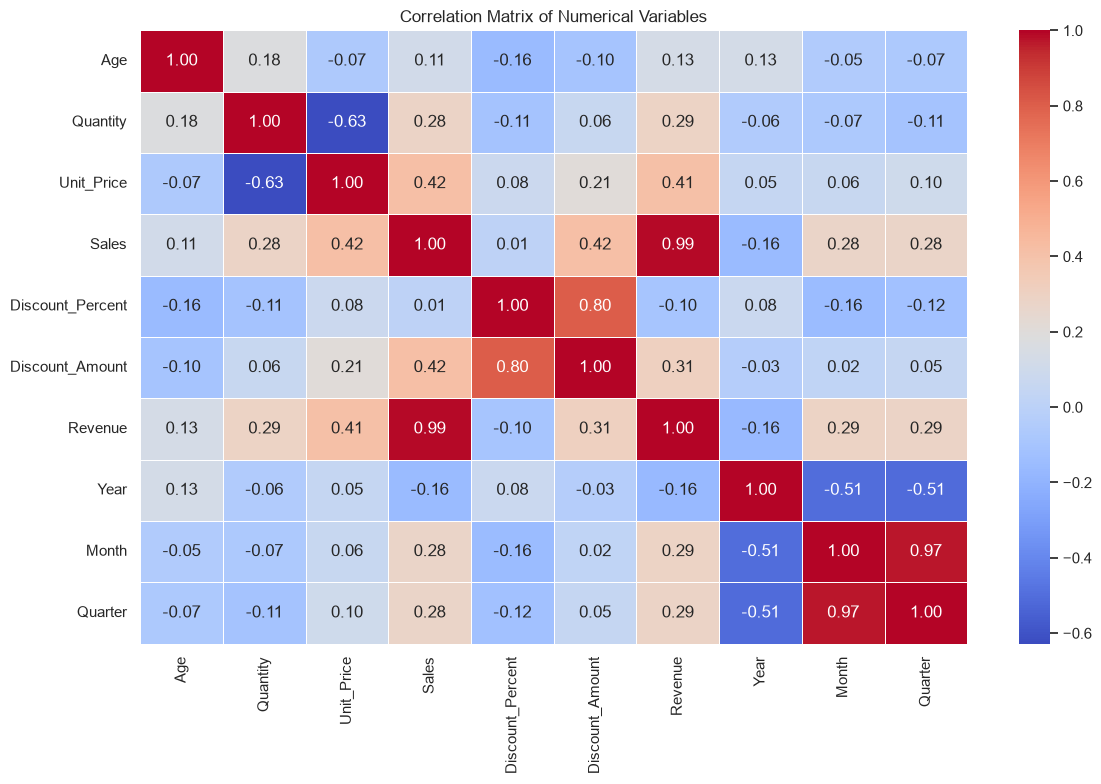

In [34]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

### Strongest Correlation

In [35]:
corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

print("Strongest Correlations:")
print(corr_pairs.head(10))

Strongest Correlations:
Sales             Revenue            0.992677
Month             Quarter            0.973519
Discount_Percent  Discount_Amount    0.802861
Quantity          Unit_Price        -0.628223
Year              Quarter           -0.509321
                  Month             -0.505253
Sales             Discount_Amount    0.420832
Unit_Price        Sales              0.418598
                  Revenue            0.411148
Discount_Amount   Revenue            0.308170
dtype: float64


## 9. Additional Business Insight

### Revenue by Product Category and Gender

This analysis compares revenue across product categories and gender
segments to identify differences in purchasing behaviour that may not
be visible from overall gender or category distributions alone.

In [36]:
category_gender_revenue = pd.pivot_table(
    df,
    values="Revenue",
    index="Category",
    columns="Gender",
    aggfunc="sum"
)

category_gender_revenue

Gender,Female,Male
Category,,
Beauty,2103.38,3394.33
Clothing,3455.41,3570.59
Electronics,3967.53,4875.07
Home & Kitchen,9415.17,5958.67
Sports,1751.37,3199.87


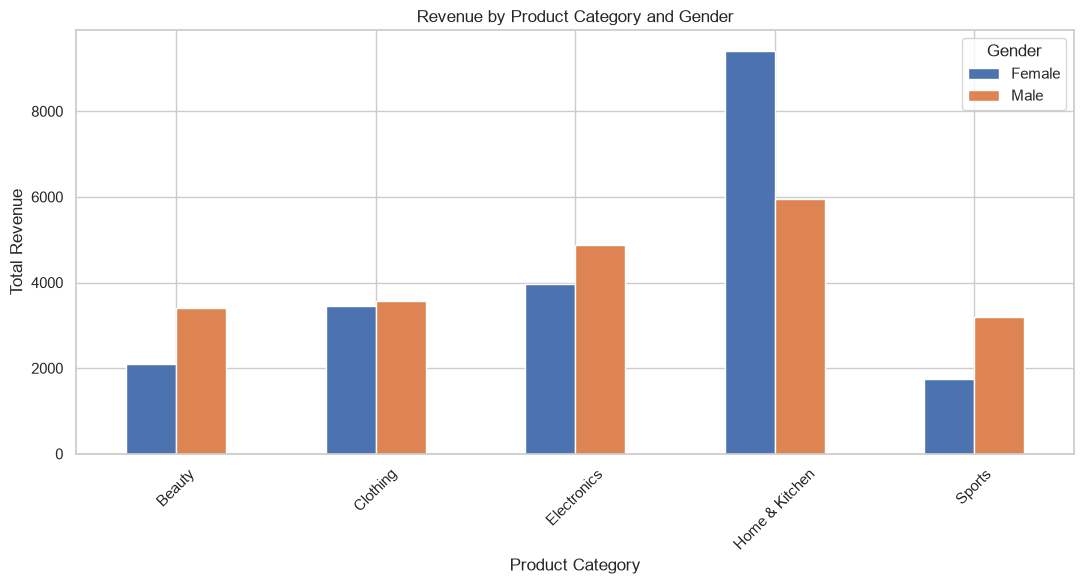

In [37]:
category_gender_revenue.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Revenue by Product Category and Gender")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The category-gender analysis provides a more detailed view of
customer purchasing behaviour.
Home & Kitchen product categories generate higher revenue from Female than Male, otherwise Male customers are dominant in other Product Categories which can help the business develop more targeted product recommendations and marketing campaigns.

### 9.1 Revenue Distribution

The distribution of transaction revenue is analyzed to understand
how frequently different revenue levels occur.

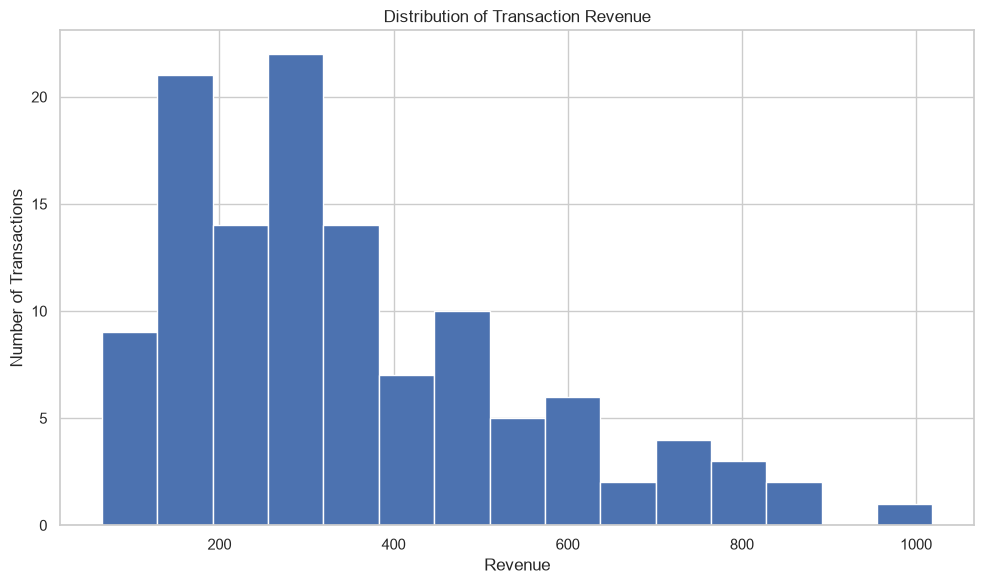

In [38]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Revenue"],
    bins=15
)

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

### Key Findings

Based on the exploratory analysis, the following major findings were
identified:

1. Monthly Highest Sales Month was 2025-11 sales were 4480.19, the Lowest Sales Month was 2025-06
   and quarterly sales(Highest Quarterly Sales were in 2025-Q4, Lowest Quarterly Sales were in 2026-Q1.)
   show variations in business performance over time.

3. Customer demographics reveal the dominant age group were between 46-55.

4. A small group of products contributes significantly to overall
   sales volume.

5. Revenue contribution in Home & Kitchen was the Highest - 15373.84.

6. The correlation analysis reveals relationships between sales,
   quantity, price, discounts, and revenue.

7. Category and gender analysis provides Home & Kitchen product categories generate higher revenue from Female than Male, otherwise Male customers are    dominant in other Product Categories.

# 11. Business Recommendations

Based on the findings from the exploratory data analysis, the
following actionable recommendations are proposed:

### 1. Optimize Inventory for Best-Selling Products

The business should maintain sufficient inventory for the
highest-selling products to reduce the risk of stockouts and
maximize sales opportunities.

### 2. Target High-Value Customer Segments

Marketing campaigns should focus on the most active age groups and
customer segments identified in the demographic analysis. Targeted
offers can improve customer engagement and conversion.

### 3. Strengthen High-Revenue Product Categories

Categories generating the highest revenue should receive greater
attention in inventory planning, promotions, and product expansion.

### 4. Use Seasonal Sales Patterns

Monthly and quarterly sales trends should be used to plan inventory
and promotional campaigns ahead of high-demand periods.

### 5. Develop Category-Specific Marketing

Differences in purchasing behaviour across gender and product
categories can be used to create more personalized marketing
campaigns and product recommendations.

# 12. Conclusion

The Exploratory Data Analysis provided valuable insights into the
retail sales dataset, including sales trends, customer demographics,
product performance, category revenue, and relationships between
numerical variables.

Time-series analysis helped identify changes in sales across months
and quarters, while demographic analysis highlighted important
customer segments. Product and category analysis identified
high-performing products and revenue-generating categories.

Overall, the analysis demonstrates how retail businesses can use
historical sales and customer data to improve inventory planning,
customer targeting, promotional strategies, and overall business
decision-making.

## 13. EDA Summary

In [39]:
summary = {
    "Total Orders": len(df),
    "Unique Customers": df["Customer_ID"].nunique(),
    "Total Quantity Sold": df["Quantity"].sum(),
    "Total Sales": df["Sales"].sum(),
    "Total Revenue": df["Revenue"].sum(),
    "Average Order Revenue": df["Revenue"].mean(),
    "Best-Selling Product": best_product,
    "Highest Revenue Category": best_category,
    "Most Common Age Group": top_age_group
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Total Orders,120
1,Unique Customers,53
2,Total Quantity Sold,564
3,Total Sales,44605.2
4,Total Revenue,41691.39
5,Average Order Revenue,347.42825
6,Best-Selling Product,T-Shirt
7,Highest Revenue Category,Home & Kitchen
8,Most Common Age Group,46-55


In [40]:
print("===== FINAL DATASET CHECK =====")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Total Sales:", round(df["Sales"].sum(), 2))
print("Total Revenue:", round(df["Revenue"].sum(), 2))
print("Unique Customers:", df["Customer_ID"].nunique())
print("Unique Products:", df["Product"].nunique())
print("Unique Categories:", df["Category"].nunique())

===== FINAL DATASET CHECK =====
Rows: 120
Columns: 18
Missing Values: 0
Duplicate Rows: 0
Total Sales: 44605.2
Total Revenue: 41691.39
Unique Customers: 53
Unique Products: 25
Unique Categories: 5
